<a href="https://colab.research.google.com/github/clarkti5/introduction-to-statistics/blob/main/3_2_Conditional_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional probability

---

#### Summary videos

- [Probability trees](https://youtu.be/HxEz4ZHUY5Y?si=pAoCNMYxSchdE8oA) (8 minutes)
- [Bayes' theorem: the geometry of changing beliefs](https://youtu.be/HZGCoVF3YvM?si=dxTaFzhq5i_AZuW9) (15 minutes)

#### Walkthrough videos

- [Exploring conditional probability](https://drive.google.com/file/d/147vysFn63fsXyqqjVi440nRHoPZ2uyD_/view?usp=sharing) (14 minutes)
- [Marginal, joint, and conditional probabilities](https://drive.google.com/file/d/1l09y4h1zqtNUDCRIjhFx4kjQB5oRe2kw/view?usp=sharing) (11 minutes)
- [Tree diagrams](https://drive.google.com/file/d/1V380Gr6SMcukTzgtsXLgfKx4GyV1A_uS/view?usp=sharing) (4 minutes)
- [Bayes' theorem](https://drive.google.com/file/d/1DWDQOoQZqb5RDyRZbcV4YMU7BdYMn7bz/view?usp=sharing) (12 minutes)

---

Sometimes, knowing that a certain event has already occured can effect the likelihood of another event occuring. For example, if two events are disjoint, then knowing that one of them has occurred ensures that the other has *not* occurred.

### Exercise

* What is the probability of drawing a diamond *given* that you drew a face card? Is this different than the probability of drawing a diamond in general? Why do you think that is?
* Is this different than the probability of drawing a face card given that you drew a diamond?
* Suppose you've drawn a diamond. If you draw another card without replacing the one you've already drawn, what is the probability of drawing another diamond?

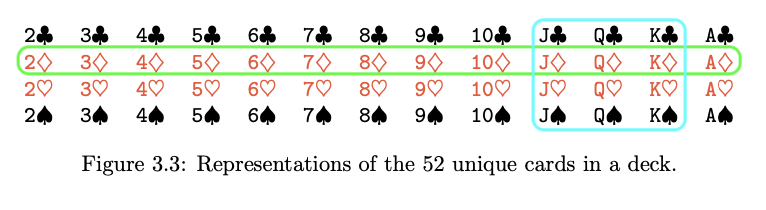

## Exploring probabilities with a contingency table

We'll investigate the `photo_classify` data set, which contains data on a machine learning algorithm's attempts to classify a given picture as related to fashion or not.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

photo_classify = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/photo_classify.csv')

In [ ]:
photo_classify.head()

,mach_learn,truth
0,pred_fashion,fashion
1,pred_fashion,fashion
2,pred_fashion,fashion
3,pred_fashion,fashion
4,pred_fashion,fashion


In [ ]:
photo_classify.tail()

,mach_learn,truth
1817,pred_not,not
1818,pred_not,not
1819,pred_not,not
1820,pred_not,not
1821,pred_not,not


We can summarize this data with a contingency table.

In [ ]:
pd.crosstab(photo_classify['mach_learn'], photo_classify['truth'], margins = True, margins_name = 'Total')

truth,fashion,not,Total
mach_learn,,,
pred_fashion,197,22,219
pred_not,112,1491,1603
Total,309,1513,1822


### Exercise

* What is the probability that `mach_learn` is `pred_fashion`?
* What is the probability that `mach_learn` is `pred_fashion` and `truth` is `fashion`?
* What is the probability that `mach_learn` is `pred_fashion` *given* that `truth` is `fashion`?

### Exercise
Draw a Venn diagram to represent the previous exercise.

#### Solution

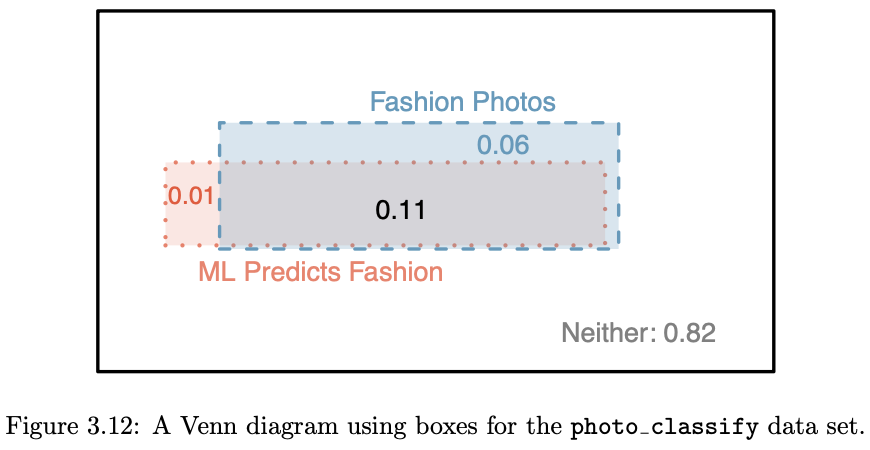

## Marginal, joint, and conditional probabilities

* If a probability is based on a single variable it is called a **marginal probability**.
* If the probability is based on two or more outcomes, it is called a **joint probability**.
* If we are studying the probability of an event given that a different condition has already occured, we are studying a **conditional probability**.

### Conditional probability

The conditional probability of $A$ given $B$ is computed by
$$ P(A\ |\ B) = \dfrac{P(A \text{ and } B)}{P(B)}. $$

### Example

Use the formula above to compute the conditional probability that `mach_learn` is `pred_fasion` given that `truth` is `not`.

### General multiplication rule

Rearranging the equation for conditional probability yields
$$ P(A \text{ and } B) = P(A|B) \cdot P(B). $$

This is a general multiplication rule that can be used for non-independent events.

### Exercise
* Suppose $A$ and $B$ are independent events. What is $P(A | B)$? What about $P(B | A)$?
* Rewrite the general multiplication rule in the case that $A$ and $B$ are independent events.

## Tree diagrams

**Tree diagrams** are useful tool to visualize sequences of random processes. Consider this example from page 102 of the textbook.

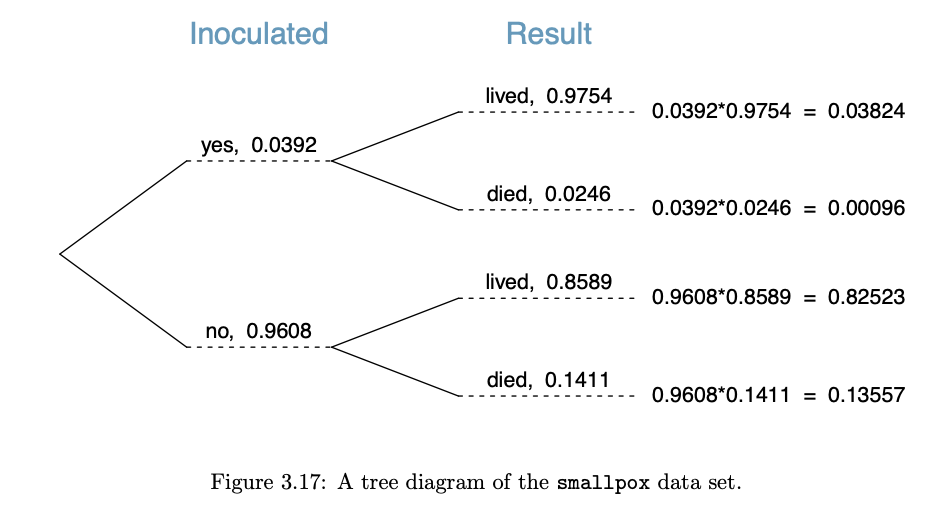

* The first branch is labeled with the marginal probabilities of the `inoculated` variable.
* The next branches are labeled with the conditional probabilities of `result` given the appropriate condition on `inoculated`.
* The joint probabilities are computed on the far right, using the general multiplication rule.

### Exercise

* What is the probability that `inoculated` is `yes`?
* What is the probability that the person died, given that they were inoculated?
* What is the probability that `inoculated` is `yes` and `result` is `died`?

## Bayes' theorem

### Example

Refer to the tree diagram for the `smallpox` data set.

* What is the probability that `result` is `died` given that `inoculation` is `no`?
* What is the probability that `inoculation` is `no` given that `result` is `died`?


The second question is more difficult, but inverting the conditions is possible through Bayes's theorem. The precises statement is below, but let's do one more example.

### Example

What is the probability that `inoculation` is `no` given that `result` is `lived`?

We can also summarize the `smallpox` data set with a contingency table, as below. Note, the exact numbers are slightly different from those represented in the textbook, but they are approximately the same.

In [ ]:
smallpox = pd.read_csv('https://raw.githubusercontent.com/clarkti5/math-209-data-sets/main/smallpox.csv')

pd.crosstab(smallpox['inoculated'], smallpox['result'], margins = True, margins_name = 'Marginal Prob.', normalize = True)

result,died,lived,Marginal Prob.
inoculated,,,
no,0.135604,0.825193,0.960797
yes,0.000964,0.038239,0.039203
Marginal Prob.,0.136568,0.863432,1.000000


### Exercise
The key insight to Bayes's theorem is that the marginal probabilities

* $P(\text{result is lived})$
* $P(\text{result is died})$

can be found as the *sum* of the joint probabilities across the disjoint outcomes of the `inoculated` variable.

Verify from the contingency table for `smallpox` that

* $P(\text{result is lived}) = P(\text{result is lived and inoculated is yes}) + P(\text{result is lived and inoculated is no})$
* $P(\text{result is died}) = P(\text{result is died and inoculated is yes}) + P(\text{result is died and inoculated is no}).$

### Bayes's theorem: inverting probabilities

From page 106 of the textbook, below is the formal statement of Bayes's theorem.

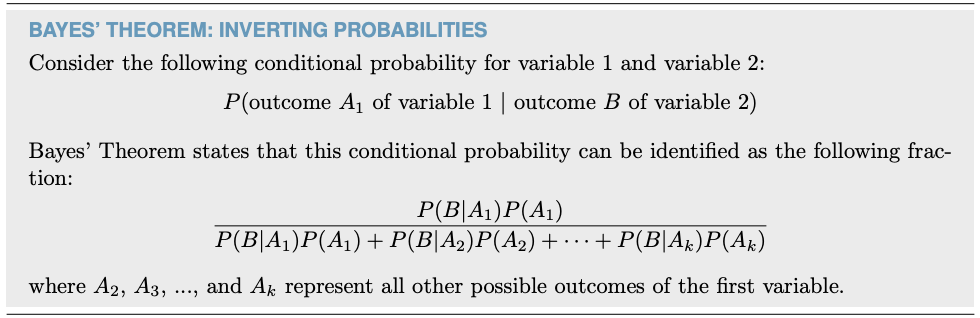

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.